# DRLB DQN and RewardNet tuning on a train/val split

This notebook turns `RND42N10Config` into a reusable train/val experiment setup.

It does four things:
1. Creates `RND42TrainValConfig` data files by splitting the original train campaigns into train and validation subsets.
2. Makes the DRLB training pipeline explicit, including where `DQN`, `RewardNet`, `lambda`, and rewards interact.
3. Tunes internal DRLB hyperparameters such as `dqn_gamma`, `dqn_lr`, `dqn_target_update_interval`, and `reward_net_lr` on the validation split.
4. Plots the training diagnostics that already exist inside DRLB: `dqn_loss`, `reward_net_loss`, `reward_signal`, `lambda`, `eps`, and selected DQN actions.

Notes:
- In `RND42TrainValConfig`, the `test` slot is intentionally reused as the validation split.
- The first steps usually show zero losses because both replay buffers need to warm up before gradient updates start.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from IPython.display import display

notebook_dir = Path().resolve()
example_notebooks_dir = notebook_dir.parent.parent
bat_autobidding_dir = example_notebooks_dir.parent

if str(example_notebooks_dir) not in sys.path:
    sys.path.insert(0, str(example_notebooks_dir))
if str(bat_autobidding_dir) not in sys.path:
    sys.path.insert(0, str(bat_autobidding_dir))

from experiments.exp_configs import RND42N10Config, RND42TrainValConfig
from simulator.model.drlb_bidder import DRLBBidder
from simulator.validation.check_results import autobidder_check

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
source_config = RND42N10Config()
config = RND42TrainValConfig()
config.ensure_artifact_dirs()
config.config_dir.mkdir(parents=True, exist_ok=True)

VAL_FRACTION = 0.2
SPLIT_SEED = config.random_seed
OBJECTIVE = "clicks"
MAX_TRAIN_STEPS = None  # Set e.g. 24 * 14 for a faster smoke run.
N_TRIALS = config.n_trials

BASE_DRLB_PARAMS = {
    "max_bid": 100.0,
    "T": 72,
    "lambda_min": 1e-6,
    "lambda_max": 10.0,
    "bids_per_timestep": 1,
}

print("Source train campaigns:", source_config.data_config["train"]["campaigns_path"])
print("Source train stats:", source_config.data_config["train"]["stats_path"])
print("Train/val config dir:", config.config_dir)
print("Validation fraction:", VAL_FRACTION)
print("Trials:", N_TRIALS)

Source train campaigns: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/campaigns_fpa_filtered_train_final.csv
Source train stats: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/stats_fpa_filtered_train_final.csv
Train/val config dir: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn/config
Validation fraction: 0.2
Trials: 10


In [3]:
def ensure_train_val_split(source_config, target_config, val_fraction=0.2, seed=42):
    source_campaigns = pd.read_csv(source_config.data_config["train"]["campaigns_path"])
    source_stats = pd.read_csv(source_config.data_config["train"]["stats_path"])

    n_val = max(1, int(round(len(source_campaigns) * val_fraction)))
    val_campaigns = (
        source_campaigns
        .sample(n=n_val, random_state=seed)
        .sort_values("campaign_id")
        .reset_index(drop=True)
    )
    val_campaign_ids = set(val_campaigns["campaign_id"].astype(int).tolist())

    train_campaigns = (
        source_campaigns[~source_campaigns["campaign_id"].astype(int).isin(val_campaign_ids)]
        .sort_values("campaign_id")
        .reset_index(drop=True)
    )

    train_stats = source_stats[source_stats["campaign_id"].astype(int).isin(set(train_campaigns["campaign_id"].astype(int)))].copy()
    val_stats = source_stats[source_stats["campaign_id"].astype(int).isin(val_campaign_ids)].copy()

    train_campaigns.to_csv(target_config.data_config["train"]["campaigns_path"], index=False)
    train_stats.to_csv(target_config.data_config["train"]["stats_path"], index=False)
    val_campaigns.to_csv(target_config.data_config["test"]["campaigns_path"], index=False)
    val_stats.to_csv(target_config.data_config["test"]["stats_path"], index=False)

    metadata = {
        "source_experiment": source_config.experiment_name,
        "target_experiment": target_config.experiment_name,
        "seed": int(seed),
        "val_fraction": float(val_fraction),
        "train_campaigns": int(len(train_campaigns)),
        "val_campaigns": int(len(val_campaigns)),
        "train_stats_rows": int(len(train_stats)),
        "val_stats_rows": int(len(val_stats)),
    }
    metadata_path = target_config.config_dir / "train_val_split_metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2))
    return metadata


split_metadata = ensure_train_val_split(
    source_config=source_config,
    target_config=config,
    val_fraction=VAL_FRACTION,
    seed=SPLIT_SEED,
)

display(pd.DataFrame([split_metadata]))

,source_experiment,target_experiment,seed,val_fraction,train_campaigns,val_campaigns,train_stats_rows,val_stats_rows
0,exp_1_rnd_42_n10,exp_tune_drlb_dqn,42,0.2,1027,257,1246481,286690


## DRLB training pipeline

The updated BAT-compatible DRLB path is now campaign-aware:

1. `DRLBBidder.fit(stats_df, campaigns_df=...)` aggregates raw stats into one training row per `(campaign_id, period)`.
2. Each campaign is treated as its own episode, while each logged hour inside that campaign becomes one RL transition.
3. The state now includes campaign-aware context: remaining budget ratio, elapsed time ratio, and a log-scaled initial budget feature.
4. For each hourly step, `RlBidAgent.act(...)` computes a bid from the current `lambda`.
5. `_update_reward_cost(...)`, `_update_step()`, and `_model_upd(eval_mode=False)` keep the same DQN + RewardNet training loop, but now on campaign-specific transitions instead of a single market-wide hourly aggregate.
6. `_record_step_history()` appends the diagnostics row used below: `dqn_loss`, `reward_net_loss`, `reward_signal`, `lambda`, `eps`, and `dqn_action`.

So the notebook mainly watches the output of `step_memory`, because that is where the training losses become observable after the replay buffers warm up.

In [5]:
import numpy as np

In [6]:
train_stats_df = pd.read_csv(config.data_config["train"]["stats_path"])
val_stats_df = pd.read_csv(config.data_config["test"]["stats_path"])


train_stats_df = pd.read_csv(config.data_config["train"]["stats_path"])
val_stats_df = pd.read_csv(config.data_config["test"]["stats_path"])
train_campaigns_df = pd.read_csv(config.data_config["train"]["campaigns_path"])
val_campaigns_df = pd.read_csv(config.data_config["test"]["campaigns_path"])


def build_campaign_period_view(stats_df, campaigns_df, objective="clicks"):
    target_col = "AuctionContactsSurplus" if objective == "contacts" else "AuctionClicksSurplus"
    campaign_period_df = (
        stats_df.sort_values(["campaign_id", "period"])
        .groupby(["campaign_id", "period"], as_index=False)
        .agg(
            ctr=("CTRPredicts", "mean"),
            reward=(target_col, "sum"),
            spend=("AuctionWinBidSurplus", "sum"),
            raw_rows=("item_id", "size"),
        )
        .merge(
            campaigns_df.loc[:, ["campaign_id", "campaign_start", "campaign_end", "auction_budget"]],
            on="campaign_id",
            how="left",
        )
    )
    duration = (campaign_period_df["campaign_end"] - campaign_period_df["campaign_start"]).clip(lower=3600)
    campaign_period_df["elapsed_time_ratio"] = (
        (campaign_period_df["period"] - campaign_period_df["campaign_start"]).clip(lower=0) / duration
    ).clip(0, 1)
    campaign_period_df["initial_budget_scale"] = np.log1p(campaign_period_df["auction_budget"].clip(lower=0)) / 10.0
    return campaign_period_df


campaign_period_train_df = build_campaign_period_view(train_stats_df, train_campaigns_df, objective=OBJECTIVE)
campaign_period_val_df = build_campaign_period_view(val_stats_df, val_campaigns_df, objective=OBJECTIVE)

summary_df = pd.DataFrame(
    [
        {
            "split": "train",
            "campaigns": train_stats_df["campaign_id"].nunique(),
            "stats_rows": len(train_stats_df),
            "campaign_period_rows_seen_by_fit": len(campaign_period_train_df),
            "median_steps_per_campaign": float(campaign_period_train_df.groupby("campaign_id").size().median()),
            "reward_sum": campaign_period_train_df["reward"].sum(),
            "spend_sum": campaign_period_train_df["spend"].sum(),
            "missing_campaign_meta": int(campaign_period_train_df[["campaign_start", "campaign_end", "auction_budget"]].isna().any(axis=1).sum()),
        },
        {
            "split": "val",
            "campaigns": val_stats_df["campaign_id"].nunique(),
            "stats_rows": len(val_stats_df),
            "campaign_period_rows_seen_by_fit": len(campaign_period_val_df),
            "median_steps_per_campaign": float(campaign_period_val_df.groupby("campaign_id").size().median()),
            "reward_sum": campaign_period_val_df["reward"].sum(),
            "spend_sum": campaign_period_val_df["spend"].sum(),
            "missing_campaign_meta": int(campaign_period_val_df[["campaign_start", "campaign_end", "auction_budget"]].isna().any(axis=1).sum()),
        },
    ]
)

display(summary_df)
display(campaign_period_train_df.head())

,split,campaigns,stats_rows,campaign_period_rows_seen_by_fit,median_steps_per_campaign,reward_sum,spend_sum,missing_campaign_meta
0,train,1027,1246481,49200,25.0,264967.990662,4.913911e+08,0
1,val,257,286690,11518,25.0,68461.656383,1.299951e+08,0


,campaign_id,period,ctr,reward,spend,raw_rows,campaign_start,campaign_end,auction_budget,elapsed_time_ratio,initial_budget_scale
0,2978176,529650000,0.031135,2.216989,1582.81,25,529652891,529739291,384.0,0.000000,0.595324
1,2978176,529653600,0.015867,1.473902,2652.28,24,529652891,529739291,384.0,0.008206,0.595324
2,2978176,529657200,0.024953,2.232787,4377.37,33,529652891,529739291,384.0,0.049873,0.595324
3,2978176,529660800,0.037718,2.302937,1976.90,22,529652891,529739291,384.0,0.091539,0.595324
4,2978176,529664400,0.024103,2.775227,2918.20,29,529652891,529739291,384.0,0.133206,0.595324


In [7]:
METRIC_COLUMNS = [
    "cpc_relative",
    "rmse",
    "clicks_sum",
    "quickspend",
    "skipped_campaigns",
    "time_inference_sec",
    "time_overall_sec",
]


def score_to_dict(score, skipped_campaigns, time_inference_sec, time_overall_sec):
    return {
        "cpc_relative": float(score[0]),
        "rmse": float(score[1]),
        "clicks_sum": float(score[2]),
        "quickspend": float(score[3]),
        "skipped_campaigns": int(skipped_campaigns),
        "time_inference_sec": float(time_inference_sec),
        "time_overall_sec": float(time_overall_sec),
    }


def build_bidder_params(base_params, model_params, verbose=False):
    return {
        **base_params,
        **model_params,
        "model_path": None,
        "exp_type": "improved_drlb",
        "objective": OBJECTIVE,
        "eval_mode": True,
        "verbose": verbose,
        "use_tqdm": verbose,
        "debug_logs": False,
        "fit_log_every": 500,
        "inference_log_every": 24,
    }


def run_drlb_candidate(label, model_params, verbose=False):
    bidder_params = build_bidder_params(BASE_DRLB_PARAMS, model_params, verbose=verbose)
    bidder = DRLBBidder(bidder_params)
    bidder.fit(
        train_stats_df,
        campaigns_df=train_campaigns_df,
        max_steps=MAX_TRAIN_STEPS,
        objective=OBJECTIVE,
    )

    diagnostics = bidder.get_training_diagnostics().copy()
    diagnostics_path = config.outputs_dir / f"{label}_training_diagnostics.csv"
    diagnostics.to_csv(diagnostics_path, index=False)

    model_path = config.best_models_dir / f"{label}.pt"
    bidder.save_model(str(model_path))

    eval_params = {
        **bidder_params,
        "input_campaigns": config.data_config["test"]["campaigns_path"],
        "input_stats": config.data_config["test"]["stats_path"],
        "model_path": str(model_path),
        "eval_mode": True,
    }
    result = autobidder_check(
        bidder=DRLBBidder,
        params=eval_params,
        auction_mode=config.auction_mode,
        verbose=verbose,
        log_every_campaigns=100,
        use_tqdm=verbose,
    )

    metrics = score_to_dict(
        score=result["score"],
        skipped_campaigns=result["skipped_campaigns"],
        time_inference_sec=result["time_inference_sec"],
        time_overall_sec=result["time_overall_sec"],
    )
    metrics.update(
        {
            "label": label,
            **model_params,
            "train_steps": int(len(diagnostics)),
            "last_dqn_loss": float(diagnostics["dqn_loss"].iloc[-1]) if not diagnostics.empty else None,
            "last_reward_net_loss": float(diagnostics["reward_net_loss"].iloc[-1]) if not diagnostics.empty else None,
        }
    )

    metrics_path = config.outputs_dir / f"{label}_metrics.json"
    metrics_path.write_text(json.dumps(metrics, indent=2))

    return {
        "label": label,
        "params": bidder_params,
        "metrics": metrics,
        "diagnostics": diagnostics,
        "model_path": model_path,
        "diagnostics_path": diagnostics_path,
        "metrics_path": metrics_path,
    }

In [8]:
baseline_model_params = {
    "dqn_gamma": 1.0,
    "dqn_lr": 1e-4,
    "dqn_target_update_interval": 100,
    "reward_net_lr": 1e-3,
}

baseline_run = run_drlb_candidate(
    label="baseline_manual",
    model_params=baseline_model_params,
    verbose=False,
)

display(pd.DataFrame([baseline_run["metrics"]]))

,cpc_relative,rmse,clicks_sum,quickspend,skipped_campaigns,time_inference_sec,time_overall_sec,label,dqn_gamma,dqn_lr,dqn_target_update_interval,reward_net_lr,train_steps,last_dqn_loss,last_reward_net_loss
0,9688.715969,1.236566,23.7021,0.0,0,21.674209,29.228423,baseline_manual,1.0,0.0001,100,0.001,49200,0.413489,10.926991


In [9]:
RUN_TUNING = True

if RUN_TUNING:
    def objective(trial):
        model_params = {
            "dqn_gamma": trial.suggest_float("dqn_gamma", 0.90, 1.0),
            "dqn_lr": trial.suggest_float("dqn_lr", 1e-5, 5e-3, log=True),
            "dqn_target_update_interval": trial.suggest_int("dqn_target_update_interval", 10, 300, step=10),
            "reward_net_lr": trial.suggest_float("reward_net_lr", 1e-5, 5e-2, log=True),
        }
        run = run_drlb_candidate(
            label=f"trial_{trial.number:03d}",
            model_params=model_params,
            verbose=False,
        )
        metrics = run["metrics"]
        trial.set_user_attr("rmse", metrics["rmse"])
        trial.set_user_attr("clicks_sum", metrics["clicks_sum"])
        trial.set_user_attr("cpc_relative", metrics["cpc_relative"])
        trial.set_user_attr("quickspend", metrics["quickspend"])
        trial.set_user_attr("last_dqn_loss", metrics["last_dqn_loss"])
        trial.set_user_attr("last_reward_net_loss", metrics["last_reward_net_loss"])
        return metrics["clicks_sum"]

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=config.random_seed),
    )
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    best_model_params = study.best_trial.params
else:
    study = None
    best_model_params = baseline_model_params.copy()

best_model_params

[I 2026-03-30 00:36:43,558] A new study created in memory with name: no-name-0a9ce638-52a2-4310-a34a-720abfd3f8e7
[I 2026-03-30 00:39:15,765] Trial 0 finished with value: 19.845608209265297 and parameters: {'dqn_gamma': 0.9374540118847363, 'dqn_lr': 0.0036808608148776113, 'dqn_target_update_interval': 220, 'reward_net_lr': 0.0016383993835282328}. Best is trial 0 with value: 19.845608209265297.
[I 2026-03-30 00:41:38,044] Trial 1 finished with value: 23.702099678335003 and parameters: {'dqn_gamma': 0.9156018640442437, 'dqn_lr': 2.6364803038431647e-05, 'dqn_target_update_interval': 20, 'reward_net_lr': 0.015994091701280463}. Best is trial 1 with value: 23.702099678335003.
[I 2026-03-30 00:44:06,036] Trial 2 finished with value: 451.00592025938647 and parameters: {'dqn_gamma': 0.9601115011743209, 'dqn_lr': 0.000814829321010529, 'dqn_target_update_interval': 10, 'reward_net_lr': 0.03869612257414272}. Best is trial 2 with value: 451.00592025938647.
[I 2026-03-30 00:46:31,518] Trial 3 finish

{'dqn_gamma': 0.9601115011743209,
 'dqn_lr': 0.000814829321010529,
 'dqn_target_update_interval': 10,
 'reward_net_lr': 0.03869612257414272}

In [10]:
best_run = run_drlb_candidate(
    label="best_trainval",
    model_params=best_model_params,
    verbose=False,
)

comparison_df = pd.DataFrame([baseline_run["metrics"], best_run["metrics"]])
display(comparison_df.sort_values("clicks_sum", ascending=False))

if study is not None:
    trials_df = study.trials_dataframe()
    display(trials_df.sort_values("value", ascending=False).head(N_TRIALS))

,cpc_relative,rmse,clicks_sum,quickspend,skipped_campaigns,time_inference_sec,time_overall_sec,label,dqn_gamma,dqn_lr,dqn_target_update_interval,reward_net_lr,train_steps,last_dqn_loss,last_reward_net_loss
1,9299.611312,1.236342,451.00592,0.0,0,21.804587,25.957626,best_trainval,0.960112,0.000815,10,0.038696,49200,0.119971,11.564022
0,9688.715969,1.236566,23.70210,0.0,0,21.674209,29.228423,baseline_manual,1.000000,0.000100,100,0.001000,49200,0.413489,10.926991


,number,value,datetime_start,datetime_complete,duration,params_dqn_gamma,params_dqn_lr,params_dqn_target_update_interval,params_reward_net_lr,user_attrs_clicks_sum,user_attrs_cpc_relative,user_attrs_last_dqn_loss,user_attrs_last_reward_net_loss,user_attrs_quickspend,user_attrs_rmse,state
2,2,451.005920,2026-03-30 00:41:38.045543,2026-03-30 00:44:06.035787,0 days 00:02:27.990244,0.960112,0.000815,10,0.038696,451.005920,9299.611312,0.119971,11.564022,0.0,1.236342,COMPLETE
4,4,23.805717,2026-03-30 00:46:31.518480,2026-03-30 00:49:00.525126,0 days 00:02:29.006646,0.930424,0.000261,130,0.000119,23.805717,9688.715969,0.525207,55.859962,0.0,1.236566,COMPLETE
1,1,23.702100,2026-03-30 00:39:15.765953,2026-03-30 00:41:38.044701,0 days 00:02:22.278748,0.915602,0.000026,20,0.015994,23.702100,9688.715969,3.022905,11.967241,0.0,1.236566,COMPLETE
3,3,23.702100,2026-03-30 00:44:06.038295,2026-03-30 00:46:31.517944,0 days 00:02:25.479649,0.983244,0.000037,60,0.000048,23.702100,9688.715969,0.408078,54.698555,0.0,1.236566,COMPLETE
5,5,23.702100,2026-03-30 00:49:00.525692,2026-03-30 00:51:34.152622,0 days 00:02:33.626930,0.961185,0.000024,90,0.000227,23.702100,9688.715969,0.626529,55.964073,0.0,1.236566,COMPLETE
7,7,23.702100,2026-03-30 00:54:05.345887,2026-03-30 00:56:33.993528,0 days 00:02:28.647641,0.959241,0.000013,190,0.000043,23.702100,9688.715969,0.472265,30.886566,0.0,1.236566,COMPLETE
9,9,23.702100,2026-03-30 00:58:56.684941,2026-03-30 01:01:24.586139,0 days 00:02:27.901198,0.930461,0.000018,210,0.000425,23.702100,9688.715969,0.832303,57.229820,0.0,1.236566,COMPLETE
0,0,19.845608,2026-03-30 00:36:43.559047,2026-03-30 00:39:15.765177,0 days 00:02:32.206130,0.937454,0.003681,220,0.001638,19.845608,9766.536976,0.748039,53.623936,0.0,1.236563,COMPLETE
6,6,8.237415,2026-03-30 00:51:34.154337,2026-03-30 00:54:05.344971,0 days 00:02:31.190634,0.945607,0.001316,60,0.000798,8.237415,9805.447475,0.513689,9.494023,0.0,1.236585,COMPLETE
8,8,8.237415,2026-03-30 00:56:33.994229,2026-03-30 00:58:56.684367,0 days 00:02:22.690138,0.906505,0.003639,290,0.009778,8.237415,9805.447475,0.612311,49.574924,0.0,1.236585,COMPLETE


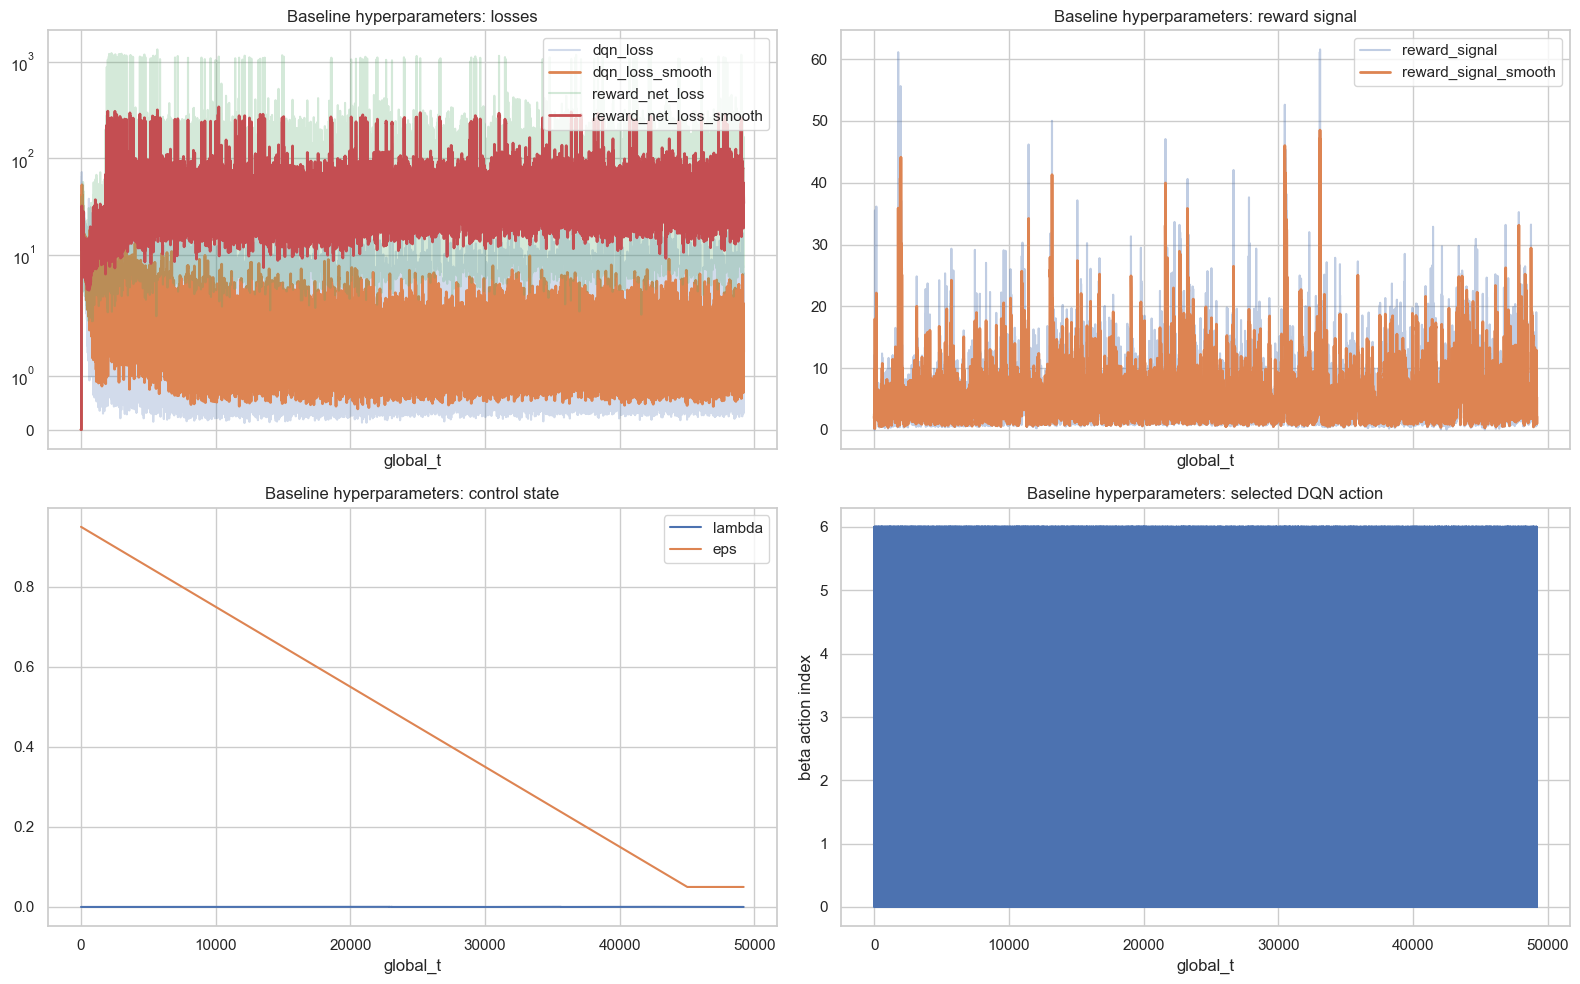

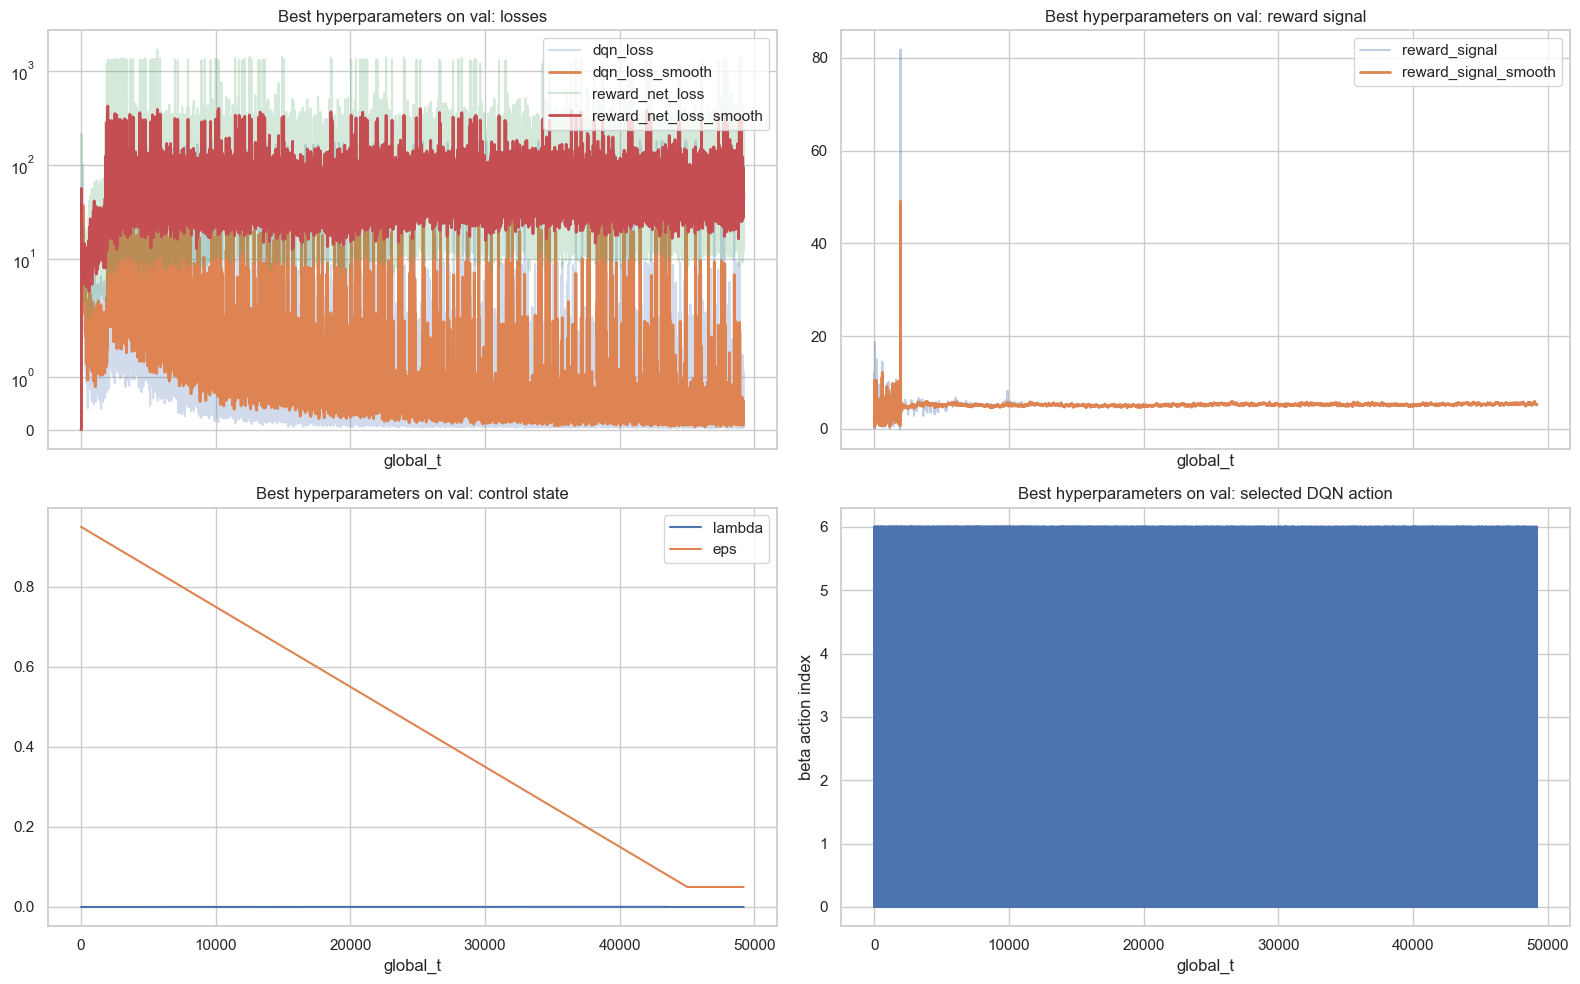

In [11]:
def plot_diagnostics(diagnostics_df, title, smoothing_window=5):
    if diagnostics_df.empty:
        print(f"No diagnostics recorded for {title}.")
        return

    plot_df = diagnostics_df.copy()
    for column in ["dqn_loss", "reward_net_loss", "reward_signal", "lambda", "eps"]:
        plot_df[f"{column}_smooth"] = plot_df[column].rolling(smoothing_window, min_periods=1).mean()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

    axes[0, 0].plot(plot_df["global_t"], plot_df["dqn_loss"], alpha=0.25, label="dqn_loss")
    axes[0, 0].plot(plot_df["global_t"], plot_df["dqn_loss_smooth"], linewidth=2, label="dqn_loss_smooth")
    axes[0, 0].plot(plot_df["global_t"], plot_df["reward_net_loss"], alpha=0.25, label="reward_net_loss")
    axes[0, 0].plot(plot_df["global_t"], plot_df["reward_net_loss_smooth"], linewidth=2, label="reward_net_loss_smooth")
    axes[0, 0].set_title(f"{title}: losses")
    axes[0, 0].set_yscale("symlog")
    axes[0, 0].legend()

    axes[0, 1].plot(plot_df["global_t"], plot_df["reward_signal"], alpha=0.35, label="reward_signal")
    axes[0, 1].plot(plot_df["global_t"], plot_df["reward_signal_smooth"], linewidth=2, label="reward_signal_smooth")
    axes[0, 1].set_title(f"{title}: reward signal")
    axes[0, 1].legend()

    axes[1, 0].plot(plot_df["global_t"], plot_df["lambda"], label="lambda")
    axes[1, 0].plot(plot_df["global_t"], plot_df["eps"], label="eps")
    axes[1, 0].set_title(f"{title}: control state")
    axes[1, 0].legend()

    axes[1, 1].step(plot_df["global_t"], plot_df["dqn_action"], where="post")
    axes[1, 1].set_title(f"{title}: selected DQN action")
    axes[1, 1].set_ylabel("beta action index")

    for ax in axes.flat:
        ax.set_xlabel("global_t")

    plt.tight_layout()
    plt.show()


plot_diagnostics(baseline_run["diagnostics"], title="Baseline hyperparameters")
plot_diagnostics(best_run["diagnostics"], title="Best hyperparameters on val")

In [12]:
artifacts_df = pd.DataFrame(
    [
        {
            "label": baseline_run["label"],
            "model_path": str(baseline_run["model_path"]),
            "diagnostics_path": str(baseline_run["diagnostics_path"]),
            "metrics_path": str(baseline_run["metrics_path"]),
        },
        {
            "label": best_run["label"],
            "model_path": str(best_run["model_path"]),
            "diagnostics_path": str(best_run["diagnostics_path"]),
            "metrics_path": str(best_run["metrics_path"]),
        },
    ]
)

display(artifacts_df)

print("Warm-up reminder: losses stay at 0 until replay buffers have more than 32 campaign-hour transitions.")
print("State reminder: training now uses campaign-aware features for budget left, elapsed time, and initial budget scale.")
print("Validation reminder: this notebook uses RND42TrainValConfig.test as the validation split.")

,label,model_path,diagnostics_path,metrics_path
0,baseline_manual,/Users/amsafin/code/local_ml/rl/bat-autobiddin...,/Users/amsafin/code/local_ml/rl/bat-autobiddin...,/Users/amsafin/code/local_ml/rl/bat-autobiddin...
1,best_trainval,/Users/amsafin/code/local_ml/rl/bat-autobiddin...,/Users/amsafin/code/local_ml/rl/bat-autobiddin...,/Users/amsafin/code/local_ml/rl/bat-autobiddin...


Warm-up reminder: losses stay at 0 until replay buffers have more than 32 campaign-hour transitions.
State reminder: training now uses campaign-aware features for budget left, elapsed time, and initial budget scale.
Validation reminder: this notebook uses RND42TrainValConfig.test as the validation split.
